# 01 - Exploración de Datos

Análisis exploratorio del dataset de intenciones para el chatbot de **Los Motes de la Magdalena**.

## Objetivos:
1. Cargar y entender la estructura del dataset
2. Analizar la distribución de intents (clases)
3. Verificar el balance de las clases
4. Analizar la longitud de los textos
5. Identificar posibles problemas en los datos

## 1. Importar librerías necesarias

Usaremos pandas para manipulación de datos, matplotlib y seaborn para visualizaciones.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from collections import Counter

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


## 2. Cargar el dataset

El archivo `intents.jsonl` contiene ejemplos de texto con sus etiquetas (intents).
Cada línea es un objeto JSON con la estructura: `{"text": "...", "label": "..."}`

In [2]:
# Cargar datos desde el archivo JSONL
data = []
with open('../data/intents.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():  # Ignorar líneas vacías
            data.append(json.loads(line))

# Convertir a DataFrame
df = pd.DataFrame(data)

print(f"📊 Dataset cargado exitosamente")
print(f"   Total de ejemplos: {len(df)}")
print(f"   Columnas: {list(df.columns)}")

📊 Dataset cargado exitosamente
   Total de ejemplos: 479
   Columnas: ['text', 'label']


## 3. Vista previa del dataset

Veamos algunos ejemplos del dataset para entender la estructura de los datos.

In [3]:
# Mostrar primeros y últimos ejemplos
print("📝 Primeros 10 ejemplos:")
display(df.head(10))

print("\n📝 Últimos 5 ejemplos:")
display(df.tail(5))

📝 Primeros 10 ejemplos:


,text,label
0,hola,saludo
1,buenos días,saludo
2,buenas tardes,saludo
3,buenas noches,saludo
4,hola que tal,saludo
5,hey,saludo
6,hola quiero pedir,saludo
7,buen día necesito información,saludo
8,holaaa,saludo
9,ola buenas,saludo



📝 Últimos 5 ejemplos:


,text,label
474,me das tu numero,fallback
475,venden pizzas,fallback
476,tienen hamburguesas,fallback
477,hay sushi,fallback
478,venden tacos,fallback


## 4. Análisis de Intents (Clases)

Contamos cuántos intents únicos tenemos y cuántos ejemplos hay por cada uno.
Esto nos ayuda a identificar si hay **desbalance de clases** (algunos intents con muchos ejemplos y otros con pocos).

In [4]:
# Contar intents únicos
intents = df['label'].unique()
print(f"🏷️ Total de intents únicos: {len(intents)}")
print(f"\n📋 Lista de intents:\n")
for i, intent in enumerate(sorted(intents), 1):
    count = len(df[df['label'] == intent])
    print(f"   {i:2d}. {intent}: {count} ejemplos")

🏷️ Total de intents únicos: 22

📋 Lista de intents:

    1. agradecimiento: 24 ejemplos
    2. app_movil: 9 ejemplos
    3. cancelar_pedido: 19 ejemplos
    4. confirmar_pedido: 20 ejemplos
    5. consultar_horario: 27 ejemplos
    6. consultar_menu: 51 ejemplos
    7. consultar_precio: 39 ejemplos
    8. consultar_ubicacion: 27 ejemplos
    9. delivery: 18 ejemplos
   10. despedida: 22 ejemplos
   11. fallback: 34 ejemplos
   12. hablar_humano: 17 ejemplos
   13. info_empresa: 9 ejemplos
   14. metodos_pago: 13 ejemplos
   15. modificar_pedido: 22 ejemplos
   16. opinion_comida: 10 ejemplos
   17. queja: 10 ejemplos
   18. realizar_pedido: 47 ejemplos
   19. reservacion: 12 ejemplos
   20. retiro_local: 10 ejemplos
   21. saludo: 30 ejemplos
   22. trabajo: 9 ejemplos


## 5. Distribución de clases (Visualización)

Un gráfico de barras nos permite ver rápidamente qué intents tienen más ejemplos.
**Ideal**: Todas las barras deberían tener altura similar (dataset balanceado).

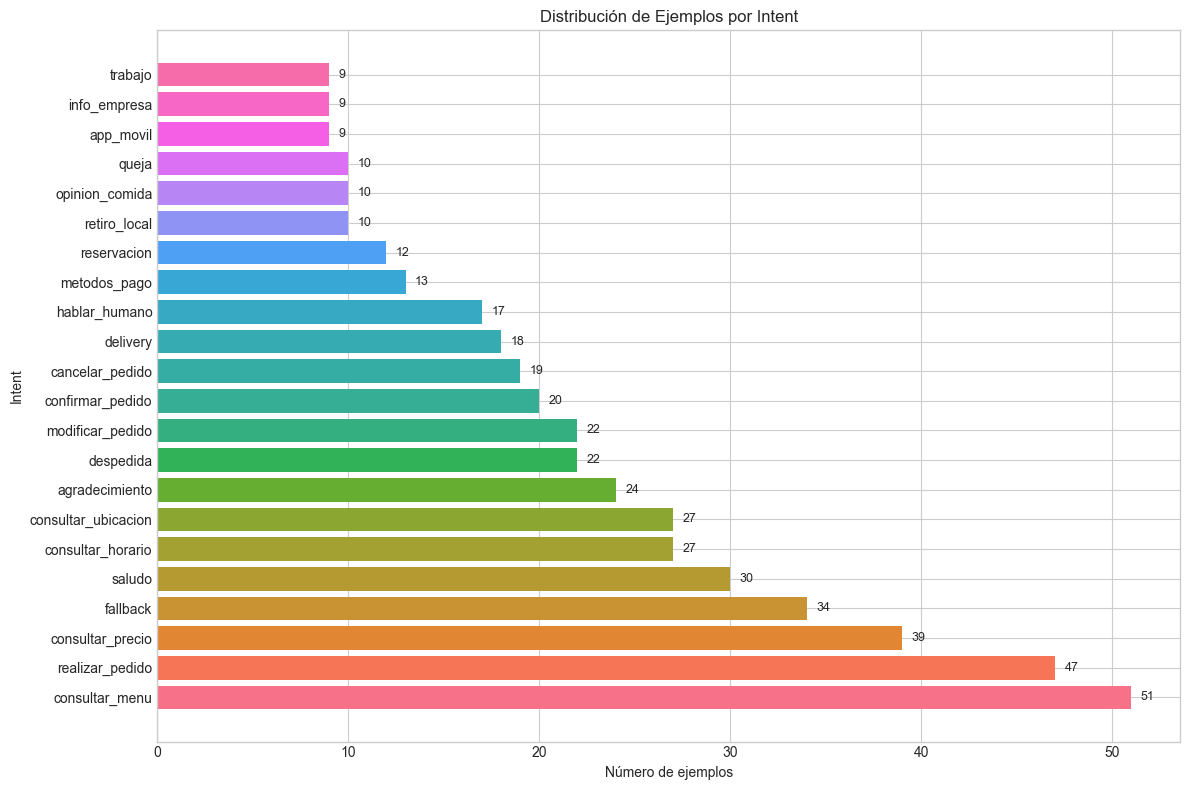


📊 Estadísticas de distribución:
   Media de ejemplos por intent: 21.8
   Mínimo: 9 (app_movil)
   Máximo: 51 (consultar_menu)
   Desviación estándar: 12.3


In [5]:
# Contar ejemplos por intent
intent_counts = df['label'].value_counts()

# Crear gráfico de barras horizontal
fig, ax = plt.subplots(figsize=(12, 8))
colors = sns.color_palette("husl", len(intent_counts))
bars = ax.barh(intent_counts.index, intent_counts.values, color=colors)

# Agregar etiquetas con el conteo
for bar, count in zip(bars, intent_counts.values):
    ax.text(count + 0.5, bar.get_y() + bar.get_height()/2, 
            str(count), va='center', fontsize=9)

ax.set_xlabel('Número de ejemplos')
ax.set_ylabel('Intent')
ax.set_title('Distribución de Ejemplos por Intent')
plt.tight_layout()
plt.show()

# Estadísticas de balance
print(f"\n📊 Estadísticas de distribución:")
print(f"   Media de ejemplos por intent: {intent_counts.mean():.1f}")
print(f"   Mínimo: {intent_counts.min()} ({intent_counts.idxmin()})")
print(f"   Máximo: {intent_counts.max()} ({intent_counts.idxmax()})")
print(f"   Desviación estándar: {intent_counts.std():.1f}")

## 6. Análisis de Balance de Clases

Calculamos el **ratio de desbalance** para determinar si necesitamos técnicas de balanceo.

- Ratio < 2: Buen balance ✅
- Ratio 2-5: Desbalance moderado ⚠️
- Ratio > 5: Desbalance severo ❌

In [6]:
# Calcular ratio de desbalance
max_count = intent_counts.max()
min_count = intent_counts.min()
imbalance_ratio = max_count / min_count

print(f"⚖️ Análisis de Balance de Clases:")
print(f"   Clase con más ejemplos: {intent_counts.idxmax()} ({max_count})")
print(f"   Clase con menos ejemplos: {intent_counts.idxmin()} ({min_count})")
print(f"   Ratio de desbalance: {imbalance_ratio:.2f}")

if imbalance_ratio < 2:
    print(f"   ✅ El dataset tiene buen balance")
elif imbalance_ratio < 5:
    print(f"   ⚠️ Desbalance moderado - considerar agregar más ejemplos a clases minoritarias")
else:
    print(f"   ❌ Desbalance severo - se recomienda balancear el dataset")

# Identificar clases con pocos ejemplos (menos de 15)
clases_bajas = intent_counts[intent_counts < 15]
if len(clases_bajas) > 0:
    print(f"\n⚠️ Clases con menos de 15 ejemplos (considerar agregar más):")
    for intent, count in clases_bajas.items():
        print(f"   - {intent}: {count} ejemplos")

⚖️ Análisis de Balance de Clases:
   Clase con más ejemplos: consultar_menu (51)
   Clase con menos ejemplos: app_movil (9)
   Ratio de desbalance: 5.67
   ❌ Desbalance severo - se recomienda balancear el dataset

⚠️ Clases con menos de 15 ejemplos (considerar agregar más):
   - metodos_pago: 13 ejemplos
   - reservacion: 12 ejemplos
   - retiro_local: 10 ejemplos
   - opinion_comida: 10 ejemplos
   - queja: 10 ejemplos
   - app_movil: 9 ejemplos
   - info_empresa: 9 ejemplos
   - trabajo: 9 ejemplos


## 7. Análisis de Longitud de Textos

Analizamos cuántas palabras tienen los textos de entrenamiento.
Esto es importante porque:
- Textos muy cortos pueden no tener suficiente contexto
- Textos muy largos pueden causar overfitting

In [7]:
# Calcular longitud en palabras y caracteres
df['num_palabras'] = df['text'].apply(lambda x: len(x.split()))
df['num_caracteres'] = df['text'].apply(lambda x: len(x))

# Estadísticas de longitud
print("📏 Estadísticas de longitud de textos:")
print(f"\n   Palabras:")
print(f"      Mínimo: {df['num_palabras'].min()}")
print(f"      Máximo: {df['num_palabras'].max()}")
print(f"      Promedio: {df['num_palabras'].mean():.1f}")
print(f"      Mediana: {df['num_palabras'].median():.1f}")

print(f"\n   Caracteres:")
print(f"      Mínimo: {df['num_caracteres'].min()}")
print(f"      Máximo: {df['num_caracteres'].max()}")
print(f"      Promedio: {df['num_caracteres'].mean():.1f}")

📏 Estadísticas de longitud de textos:

   Palabras:
      Mínimo: 1
      Máximo: 9
      Promedio: 3.5
      Mediana: 4.0

   Caracteres:
      Mínimo: 2
      Máximo: 45
      Promedio: 19.8


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_30992\2228048398.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sorted, y='label', x='num_palabras', ax=axes[1], palette="husl")


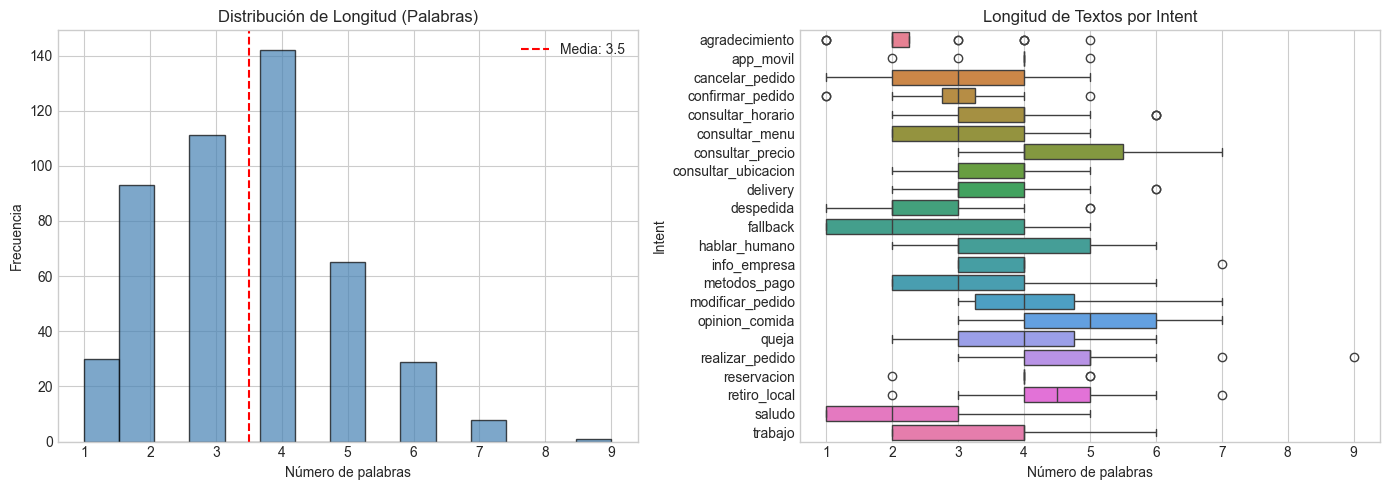

In [8]:
# Visualizar distribución de longitud
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de palabras
axes[0].hist(df['num_palabras'], bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Número de palabras')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Longitud (Palabras)')
axes[0].axvline(df['num_palabras'].mean(), color='red', linestyle='--', label=f'Media: {df["num_palabras"].mean():.1f}')
axes[0].legend()

# Boxplot por intent
df_sorted = df.sort_values('label')
axes[1].set_title('Longitud de Textos por Intent')
sns.boxplot(data=df_sorted, y='label', x='num_palabras', ax=axes[1], palette="husl")
axes[1].set_xlabel('Número de palabras')
axes[1].set_ylabel('Intent')

plt.tight_layout()
plt.show()

## 8. Análisis de Textos Muy Cortos

Los textos con 1-2 palabras pueden ser difíciles de clasificar correctamente.
Identificamos cuáles son para verificar que tengan sentido.

In [9]:
# Textos con 1-2 palabras
textos_cortos = df[df['num_palabras'] <= 2][['text', 'label', 'num_palabras']]
print(f"📝 Textos con 1-2 palabras ({len(textos_cortos)} ejemplos):\n")
display(textos_cortos.sort_values('label'))

📝 Textos con 1-2 palabras (123 ejemplos):



,text,label,num_palabras
44,super gracias,agradecimiento,2
32,te agradezco,agradecimiento,2
34,perfecto gracias,agradecimiento,2
35,mil gracias,agradecimiento,2
39,excelente gracias,agradecimiento,2
...,...,...,...
13,holi,saludo,1
0,hola,saludo,1
432,buscan empleados,trabajo,2
431,necesitan personal,trabajo,2


## 9. Verificación de Duplicados

Verificamos si hay textos duplicados que podrían afectar el entrenamiento.

In [10]:
# Buscar duplicados exactos
duplicados = df[df.duplicated(subset=['text'], keep=False)]
if len(duplicados) > 0:
    print(f"⚠️ Se encontraron {len(duplicados)} textos duplicados:")
    display(duplicados.sort_values('text'))
else:
    print("✅ No se encontraron textos duplicados")

# Buscar textos similares (mismo texto en diferentes intents)
duplicados_conflicto = df.groupby('text').filter(lambda x: x['label'].nunique() > 1)
if len(duplicados_conflicto) > 0:
    print(f"\n❌ Textos asignados a múltiples intents (conflicto):")
    display(duplicados_conflicto)
else:
    print("✅ No hay conflictos de etiquetado")

✅ No se encontraron textos duplicados
✅ No hay conflictos de etiquetado


## 10. Ejemplos por Intent

Veamos algunos ejemplos de cada intent para verificar que el etiquetado sea correcto.

In [11]:
# Mostrar 3 ejemplos de cada intent
print("📋 Ejemplos de cada intent:\n")
for intent in sorted(df['label'].unique()):
    ejemplos = df[df['label'] == intent]['text'].head(3).tolist()
    print(f"🏷️ {intent}:")
    for ej in ejemplos:
        print(f"   • \"{ej}\"")
    print()

📋 Ejemplos de cada intent:

🏷️ agradecimiento:
   • "gracias"
   • "muchas gracias"
   • "te agradezco"

🏷️ app_movil:
   • "tienen app"
   • "puedo pedir por la aplicacion"
   • "como descargo la app"

🏷️ cancelar_pedido:
   • "quiero cancelar mi pedido"
   • "anule la orden"
   • "ya no lo quiero"

🏷️ confirmar_pedido:
   • "sí confirmar pedido"
   • "confirmo mi orden"
   • "está bien así"

🏷️ consultar_horario:
   • "a qué hora abren"
   • "cuál es el horario de atención"
   • "atienden los domingos"

🏷️ consultar_menu:
   • "qué venden"
   • "me puede mostrar el menú"
   • "qué productos tienen"

🏷️ consultar_precio:
   • "cuánto cuesta el mote con chicharrón"
   • "precio del mote con cuero"
   • "cuánto vale el menú 1"

🏷️ consultar_ubicacion:
   • "dónde están ubicados"
   • "me pasa la dirección"
   • "en qué sector están"

🏷️ delivery:
   • "tienen delivery"
   • "hacen envios a domicilio"
   • "entregan a domicilio"

🏷️ despedida:
   • "adiós"
   • "hasta luego"
   • "nos ve

## 11. Resumen y Recomendaciones

Generamos un resumen final con métricas clave y recomendaciones.

In [12]:
# Resumen final
print("=" * 60)
print("📊 RESUMEN DEL DATASET")
print("=" * 60)
print(f"\n📈 Estadísticas Generales:")
print(f"   • Total de ejemplos: {len(df)}")
print(f"   • Total de intents: {len(df['label'].unique())}")
print(f"   • Promedio de ejemplos por intent: {len(df) / len(df['label'].unique()):.1f}")

print(f"\n⚖️ Balance de Clases:")
print(f"   • Ratio de desbalance: {imbalance_ratio:.2f}")
print(f"   • Clases con < 15 ejemplos: {len(intent_counts[intent_counts < 15])}")

print(f"\n📏 Longitud de Textos:")
print(f"   • Palabras promedio: {df['num_palabras'].mean():.1f}")
print(f"   • Textos muy cortos (≤2 palabras): {len(df[df['num_palabras'] <= 2])}")

print(f"\n✅ Calidad del Dataset:")
duplicados_count = df.duplicated(subset=['text']).sum()
print(f"   • Textos duplicados: {duplicados_count}")
print(f"   • Conflictos de etiquetado: {len(duplicados_conflicto)}")

print("\n" + "=" * 60)
print("💡 RECOMENDACIONES")
print("=" * 60)

recomendaciones = []
if imbalance_ratio > 3:
    recomendaciones.append("Agregar más ejemplos a las clases minoritarias")
if len(intent_counts[intent_counts < 15]) > 0:
    recomendaciones.append("Aumentar ejemplos en intents con menos de 15 muestras")
if len(df) < 500:
    recomendaciones.append("Considerar aumentar el dataset total (ideal: 500+ ejemplos)")
    
if len(recomendaciones) == 0:
    print("\n✅ El dataset está listo para entrenamiento!")
else:
    for i, rec in enumerate(recomendaciones, 1):
        print(f"\n{i}. {rec}")
        
print("\n" + "=" * 60)
print("➡️ Siguiente paso: Ejecutar 02_entrenamiento_modelo.ipynb")
print("=" * 60)

📊 RESUMEN DEL DATASET

📈 Estadísticas Generales:
   • Total de ejemplos: 479
   • Total de intents: 22
   • Promedio de ejemplos por intent: 21.8

⚖️ Balance de Clases:
   • Ratio de desbalance: 5.67
   • Clases con < 15 ejemplos: 8

📏 Longitud de Textos:
   • Palabras promedio: 3.5
   • Textos muy cortos (≤2 palabras): 123

✅ Calidad del Dataset:
   • Textos duplicados: 0
   • Conflictos de etiquetado: 0

💡 RECOMENDACIONES

1. Agregar más ejemplos a las clases minoritarias

2. Aumentar ejemplos en intents con menos de 15 muestras

3. Considerar aumentar el dataset total (ideal: 500+ ejemplos)

➡️ Siguiente paso: Ejecutar 02_entrenamiento_modelo.ipynb
